# OD Survey: Belo Horizonte

## Imports and Setup

In [131]:
from os import environ
from pathlib import Path

import geobr
import geopandas as gpd
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from scipy.stats import ecdf

In [80]:
db = Path(environ.get('DB_FOLDER'))
out_folder = Path.cwd().parent / 'outputs'

# SIRGAS 2000 / UTM zone 23S 
EPSG = 31983

In [81]:
pd.options.display.float_format = '{:,.2f}'.format

## Viagem

In [82]:
inpath = db / 'beaga/origin_destination_survey/2012/internal_trips_RMBH.csv'

hts = pd.read_csv(
    inpath,
    sep=';',
    decimal=',',
    #encoding='latin-1',
    dtype={
        'ID_DOMICILIO': int,
        'ID_PESSOA': int,
        'ID_TRAJETO': int,
        },
    parse_dates=['Hora início', 'Hora fim'],
    dayfirst=True,
)

In [83]:
swaps = {
    'Identificação1': 'id_viagem',
    'Domicilio': 'id_domicilio',
    'Pessoa': 'id_pessoa',
    'AH origem': 'id_zona_origem',
    'motivo_origem': 'motivo_origem',
    'Viagem': 'id_trajeto',
    'Hora início': 'hora_saida',
    'DS_SH_MEIO_TRANSPORTE': 'modo',
    'AH destino': 'id_zona_destino',
    'Hora fim': 'hora_chegada',
    'motivo_destino': 'motivo_destino',
    'Modos agrupados': 'modo_agregado',
    'Fator expansão': 'fator_expansao',
    }

hts = (
    hts
    .reindex(columns=swaps)
    .rename(columns=swaps)
    .dropna(subset=['id_zona_destino', 'id_zona_origem'])
    .astype({
        'id_zona_origem': 'int',
        'id_zona_destino': int,
        })
    .sort_values(['id_domicilio', 'id_pessoa', 'hora_saida'])
    .assign(
        hora_saida=lambda x: x.hora_saida.apply(
            lambda t: t.replace(year=2012)
            ),
        hora_chegada=lambda x: x.hora_chegada.apply(
            lambda t: t.replace(year=2012)
            ),
        )
        .query('modo_agregado != "Outros"')
    )

In [84]:
hts.assign(interzone=lambda x: x.id_zona_origem != x.id_zona_destino).groupby('modo_agregado').interzone.mean()

modo_agregado
Não motorizado   0.51
coletivo         0.95
individual       0.92
Name: interzone, dtype: float64

In [85]:
inpath = db / 'beaga/origin_destination_survey/2012/malha_areas_homogeneas.zip'
zones = (
    gpd
    .read_file(inpath)
    .astype({'AH2011': int})
    .rename(columns={'AH2011': 'id_zona'})
    .set_index('id_zona')
    .to_crs(31983)
    .centroid
    .to_frame('geometry')
    .reset_index()
    )

In [86]:
bh = geobr.read_municipality(3106200).to_crs(31983)[['geometry']]
zones = zones.sjoin(bh)

hts = hts.loc[hts.id_zona_origem.isin(zones.id_zona) & hts.id_zona_destino.isin(zones.id_zona)]

In [87]:
from scipy.spatial.distance import cdist


def pairwise_distances_longform(gdf, id_col=None):
    coords = np.column_stack((gdf.geometry.x, gdf.geometry.y))
    dist_matrix = cdist(coords, coords)

    # Use IDs or index as labels
    labels = gdf[id_col].to_numpy() if id_col else gdf.index.to_numpy()

    # Build long-format dataframe
    df_long = pd.DataFrame(
        dist_matrix,
        index=labels,
        columns=labels
    ).stack().reset_index()

    df_long.columns = ["origin", "destination", "distance"]

    return df_long


In [88]:
trip_distances = pairwise_distances_longform(zones, id_col='id_zona').query('origin != destination')

In [89]:
hts = hts.merge(
    trip_distances,
    how='inner',
    left_on=['id_zona_origem', 'id_zona_destino'],
    right_on=['origin', 'destination']
)

In [90]:
hts.sample(3)

,id_viagem,id_domicilio,id_pessoa,id_zona_origem,motivo_origem,id_trajeto,hora_saida,modo,id_zona_destino,hora_chegada,motivo_destino,modo_agregado,fator_expansao,origin,destination,distance
29341,77039,23453,1,1656,Saúde (Médico / Dentista / Exame Clínico ou La...,2,2012-12-30 09:50:00,A pé,1619,2012-12-30 10:00:00,Lazer (Turismo / Recreação / Visitas / Congres...,Não motorizado,133.84,1656,1619,"2,220.74"
15027,42321,13791,4,1638,Escola (Aulas / Atividades Escolares),2,2012-12-30 17:20:00,Escolar,1661,2012-12-30 17:30:00,Residência,coletivo,47.02,1638,1661,532.00
7375,21588,7713,5,1728,Residência,1,2012-12-30 07:00:00,Ônibus coletivo urbano,1009,2012-12-30 08:40:00,Trabalho (serviço),coletivo,86.53,1728,1009,"10,215.12"


<Axes: xlabel='distance', ylabel='Proportion'>

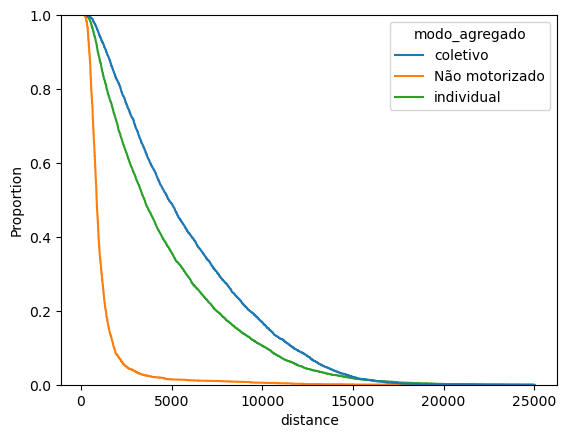

In [91]:
sns.ecdfplot(
    hts,
    x='distance',
    weights='fator_expansao',
    hue='modo_agregado',
    complementary=True,
)

In [92]:
hts.groupby('modo_agregado').distance.describe(percentiles=[.25, .5, .75, .9, .95, .99])

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
modo_agregado,,,,,,,,,,,
Não motorizado,"13,703.00","1,141.80","1,218.55",171.17,620.96,874.94,"1,247.59","1,839.73","2,500.10","6,489.72","23,364.06"
coletivo,"16,062.00","5,862.48","3,992.38",271.60,"2,568.61","4,936.10","8,498.00","11,759.05","13,399.35","16,260.13","25,029.19"
individual,"22,039.00","4,684.03","3,767.87",209.79,"1,757.38","3,557.09","6,663.10","10,285.13","12,214.19","16,245.81","24,926.70"


In [128]:
def trips_by_5min_by(df, group_col="modo_agregado",
                     time_col="hora_saida", weight_col="fator_expansao"):
    s = pd.to_datetime(df[time_col])
    df = df.assign(_ts=s).set_index("_ts").sort_index()
    wide = (df.groupby(group_col)
              .resample("60min")[weight_col]
              .sum()
              .unstack(0)
              .fillna(0))
    return wide.reset_index(names=["interval"])


In [129]:
trip_time_series = trips_by_5min_by(
    hts, group_col="modo_agregado",
    time_col="hora_saida", weight_col="fator_expansao"
    )

trip_time_series = trip_time_series.melt(
    id_vars="interval",
    var_name="modo_agregado",
    value_name="n_trips"
)

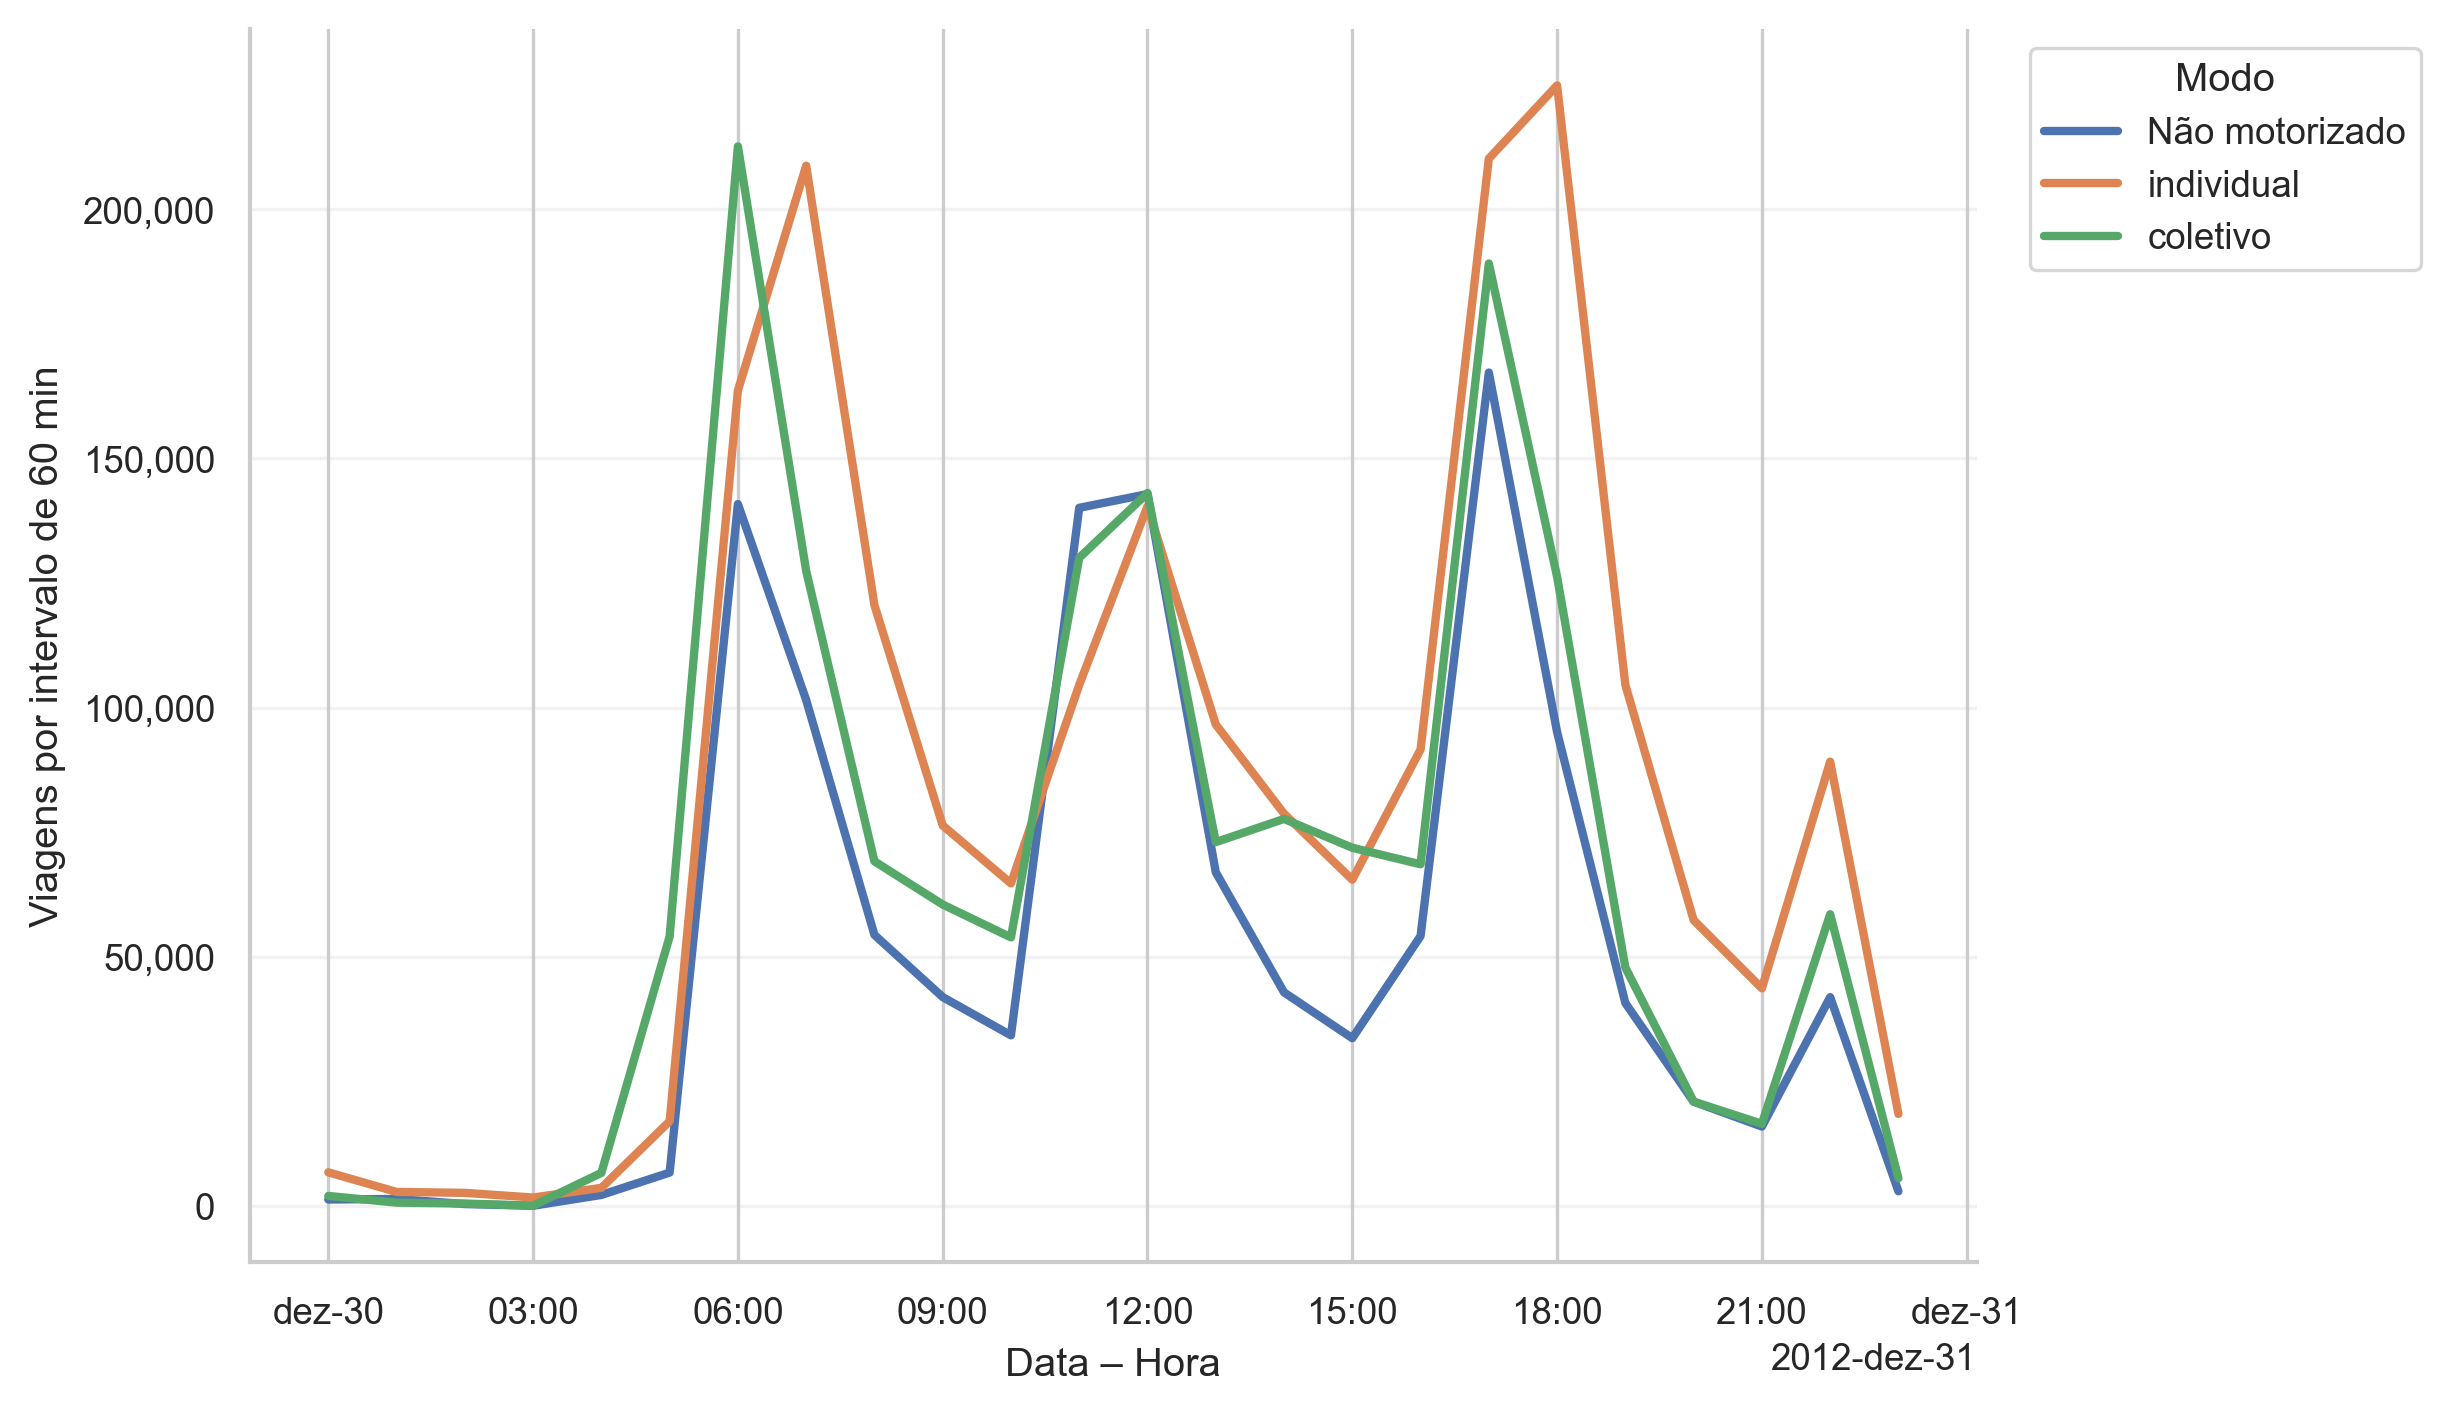

In [132]:
# --- data hygiene -----------------------------------------------------------
trip_time_series = trip_time_series.copy()
trip_time_series["interval"] = pd.to_datetime(
    trip_time_series["interval"]
)
trip_time_series = trip_time_series.sort_values("interval")

# --- aesthetics -------------------------------------------------------------
sns.set_theme(style="whitegrid", context="paper")
A4_WIDTH_IN = 8.27        # A4 width in portrait (inches)
FIG_HEIGHT_IN = 4.8       # tune to your layout
fig, ax = plt.subplots(figsize=(A4_WIDTH_IN, FIG_HEIGHT_IN), dpi=300)

# --- plot -------------------------------------------------------------------
# (data already aggregated per 5-min bin; no error bars)
sns.lineplot(
    data=trip_time_series,
    x="interval",
    y="n_trips",
    hue="modo_agregado",
    errorbar=None,
    linewidth=2,
    ax=ax,
)

# --- x-axis: clean, compact date-time labeling ------------------------------
loc = mdates.AutoDateLocator(minticks=6, maxticks=10)
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=30))

# --- labels, legend, and finishing touches ----------------------------------
ax.set_xlabel("Data – Hora")
ax.set_ylabel("Viagens por intervalo de 60 min")
sns.move_legend(
    ax, "upper left", bbox_to_anchor=(1.02, 1), title="Modo", frameon=True
)
ax.grid(axis="y", which="major", alpha=0.25)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
sns.despine(ax=ax)
fig.tight_layout()

# Optional: save at print quality
# fig.savefig("trips_time_series_a4.png", dpi=300, bbox_inches="tight")
plt.show()

## Domicílio

In [4]:
inpath = db / 'beaga/origin_destination_survey/dbo_TB_DOMICILIO_ENTREGA.csv'

domicilio = pd.read_csv(
    inpath,
    sep=';',
    decimal=',',
    encoding='latin-1',
    dtype={'AREA_HOMOGENEA': int}
    #parse_dates=['Hora início', 'Hora fim'],
    #dayfirst=True,
)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\brand\\OneDrive\\Documentos\\database\\beaga\\origin_destination_survey\\dbo_TB_DOMICILIO_ENTREGA.csv'

In [ ]:
inpath = db / 'beaga/origin_destination_survey/dbo_TB_FATOR_EXPANSÂO_DOMICÍLIO.csv'

domicilio_fator = pd.read_csv(
    inpath,
    sep=';',
    decimal=',',
    encoding='latin-1',
    dtype={'AH': int}
    #parse_dates=['Hora início', 'Hora fim'],
    #dayfirst=True,
)

In [ ]:
domicilio = domicilio.merge(domicilio_fator, left_on='AREA_HOMOGENEA', right_on='AH')

In [ ]:
automoveis = [
    'QTD_AUTOMOVEL',
    'QTD_CAMINHONETE'
]

domicilio['quantidade_automoveis'] = domicilio[automoveis].sum(1)

In [ ]:
swaps = {
    'ID_DOMICILIO': 'id_domicilio',
    'NM_CIDADE': 'nome_cidade',
    'AREA_HOMOGENEA': 'id_zona',
    'DS_TP_DOMICILIO': 'tipologia_domicilio',
    'DS_TP_REGIME_OCUPACAO': 'regime_ocupacao',
    'QTD_BICICLETA': 'quantidade_bicicletas',
    'QTD_MOTO': 'quantidade_motos',
    'QTD_PESSOAS': 'quantidade_moradores',
    'QTD_FAMILIAS': 'quantidade_familias',
    'FE': 'fator_expansao',
    }

In [ ]:
domicilio = (
    domicilio
    .reindex(columns=list(swaps.keys()) + ['quantidade_automoveis'])
    .rename(columns=swaps)
    )

In [ ]:
domicilio.head()

,id_domicilio,nome_cidade,id_zona,tipologia_domicilio,regime_ocupacao,quantidade_bicicletas,quantidade_motos,quantidade_moradores,quantidade_familias,fator_expansao,quantidade_automoveis
0,25331,BELO HORIZONTE,1311,Domicílio Isolado (casa),Alugada,0,0,4,1,55.26,2
1,25332,BELO HORIZONTE,1312,Domicílio Isolado (casa),Própria paga,0,0,1,1,52.04,0
2,25333,BELO HORIZONTE,1312,Domicílio Isolado (casa),Alugada,0,0,4,1,52.04,0
3,25334,BELO HORIZONTE,1312,Domicílio Isolado (casa),Própria paga,0,0,2,1,52.04,2
4,25335,BELO HORIZONTE,1312,Domicílio Isolado (casa),Própria paga,0,0,2,1,52.04,0


In [ ]:
def lookup_muni(city):
    return (
        geobr
        .lookup_muni(
            city
            )
        .pipe(
            lambda x: x.loc[x.abbrev_state == 'MG']
            )
        .code_muni
        .squeeze()
        )

muni_swaps = {city: lookup_muni(city) for city in domicilio.nome_cidade.unique()}

domicilio['id_municipio'] = domicilio.nome_cidade.replace(muni_swaps)

domicilio = domicilio.drop(columns='nome_cidade')

C:\Users\brand\AppData\Local\Temp\ipykernel_8536\1887013399.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  domicilio['id_municipio'] = domicilio.nome_cidade.replace(muni_swaps)


In [ ]:
domicilio.head()

,id_domicilio,id_zona,tipologia_domicilio,regime_ocupacao,quantidade_bicicletas,quantidade_motos,quantidade_moradores,quantidade_familias,fator_expansao,quantidade_automoveis,id_municipio
0,25331,1311,Domicílio Isolado (casa),Alugada,0,0,4,1,55.26,2,3106200
1,25332,1312,Domicílio Isolado (casa),Própria paga,0,0,1,1,52.04,0,3106200
2,25333,1312,Domicílio Isolado (casa),Alugada,0,0,4,1,52.04,0,3106200
3,25334,1312,Domicílio Isolado (casa),Própria paga,0,0,2,1,52.04,2,3106200
4,25335,1312,Domicílio Isolado (casa),Própria paga,0,0,2,1,52.04,0,3106200


## Pessoas

In [ ]:
inpath = db / 'beaga/origin_destination_survey/dbo_TB_DOMICILIO_PESSOA_ENTREGA.csv'

pessoa = pd.read_csv(
    inpath,
    sep=';',
    decimal=',',
    encoding='latin-1',
    #dtype={'AREA_HOMOGENEA': int}
    #parse_dates=['Hora início', 'Hora fim'],
    #dayfirst=True,
)

C:\Users\brand\AppData\Local\Temp\ipykernel_8536\256604736.py:3: DtypeWarning: Columns (55,57) have mixed types. Specify dtype option on import or set low_memory=False.
  pessoa = pd.read_csv(


In [ ]:
swaps = {
    'ID_DOMICILIO': 'id_domicilio',
    'ID_PESSOA': 'id_pessoa',
    'DS_SITUACAO_FAMILIA': 'situacao_familiar',
    'DS_SEXO': 'genero',
    'IDADE': 'idade',
    'DS_GRAU_INSTRUCAO': 'grau_instrucao',
    'DS_TRABALHA': 'indicador_trabalho',
    'DS_QUAL_SITUACAO': 'situacao_oficio',
    'DS_RENDA': 'renda_salario_minimo', 
    'DS_VINCULO_EMPREGATICIO_TRABALHO': 'condicao_atividade',
    'AREA_HOMOGENEA_TRABALHO': 'id_zona_trabalho',
    'AREA_HOMOGENEA_ESTUDO': 'id_zona_estudo',
    'DS_HORARIO_CURSO_ESTUDO': 'turno_estudo'
}

pessoa = pessoa.reindex(columns=swaps).rename(columns=swaps)

In [ ]:
pessoa.head(3)

,id_domicilio,id_pessoa,situacao_familiar,genero,idade,grau_instrucao,indicador_trabalho,situacao_oficio,renda_salario_minimo,condicao_atividade,id_zona_trabalho,id_zona_estudo,turno_estudo
0,52,2,Conjuge do(a) responsável pela família,Feminino,69,Ensino fundamental incompleto,Não,Dona de casa,Sem renda,NaN,NaN,NaN,NaN
1,52,3,Filho(a) do(a) responsável pela família,Masculino,41,Ensino fundamental incompleto,Sim,NaN,"Mais de 1 até 2 SM - Acima de R$ 622,00 até R...",Assalariado com carteira,"18,112.00",NaN,NaN
2,54,1,Responsável pela família,Masculino,53,Ensino médio completo,Sim,NaN,"Mais de 2 até 3 SM - Acima de R$ 1.244,00 até...",Assalariado com carteira,"1,122.00",NaN,NaN


In [ ]:
swaps = {
   'Mais de 1 até 2 SM - Acima de R$  622,00 até R$ 1.244,00': '1 a 2',
   'Mais de 2 até 3 SM  - Acima de R$ 1.244,00 até R$ 1.866,00': '2 a 3',
   'Mais de 5 até 10 SM - Acima de R$ 3.110,00 até R$ 6.220,00': '5 a 10',
   'Mais de 20 SM - Acima de R$ 12.440,00': '20 ou mais',
   'Mais de 3 até 5 SM  - Acima de R$ 1.866,00 até R$ 3.110,00': '3 a 5',
   'O entrevistado não quis informar a renda': 'Não informado',
   'Até 1 SM  - Até R$ 622,00': 'Até 1',
   'Mais de 10 até 15 SM  - Acima de R$ 6.220,00 até R$ 9.330,00': '10 a 15',
   'Mais de 15 até 20 SM  - Acima de R$ 9.330,00 até R$ 12.440,00': '15 a 20',
    }

pessoa = pessoa.replace({'renda_salario_minimo': swaps})

# Backup

In [25]:
def timedelta_to_min(duration):
    seconds = duration.seconds
    return seconds / 60

In [26]:
hts = (
    hts
    .loc[
        ((hts['Município destino'] == 'BELO HORIZONTE') | (hts['Município origem'] == 'BELO HORIZONTE'))
        & (hts['AH destino'] != hts['AH origem'])
        ]
    .assign(**{
        'Hora início': lambda x: pd.to_datetime(x['Hora início'], dayfirst=True),
        'Hora fim': lambda x: pd.to_datetime(x['Hora fim'], dayfirst=True),
        })
    .assign(
        duracao=lambda x: list(
            map(
                timedelta_to_min,
                x['Hora fim'] - x['Hora início'],
                )
            )
        )
    .rename(columns={'Fator expansão': 'fe_via', 'Modos agrupados': 'modo_viagem'})
    .assign(
        modo_viagem=lambda x: x.modo_viagem.str.title()
        )
    .pipe(
        lambda x: x.loc[x.modo_viagem.isin(['Coletivo', 'Individual']) | (x.DS_SH_MEIO_TRANSPORTE == 'A pé')]
        )
    .assign(
        modo_viagem=lambda df: np.where(
            df.modo_viagem == 'Não motorizado',
            'A pé',
            df.modo_viagem,
            )
        )
    .replace({'modo_viagem': {'Não Motorizado': 'A pé'}})
    .reindex(
        columns=[
            'modo_viagem',
            'fe_via',
            'duracao',
            ]
        )
    )

In [27]:
hts.head()

,modo_viagem,fe_via,duracao
0,Coletivo,117.43,75.00
1,Coletivo,117.43,60.00
2,Coletivo,99.39,110.00
3,Coletivo,110.29,110.00
4,Individual,102.78,50.00


<Axes: xlabel='duracao', ylabel='Proportion'>

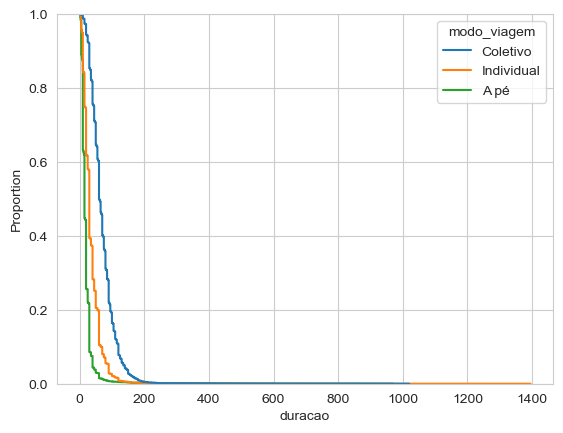

In [28]:
sns.ecdfplot(
    hts,
    x='duracao',
    weights='fe_via',
    hue='modo_viagem',
    complementary=True,
)

In [29]:
df = hts.reindex(
    hts.index.repeat(
        hts.fe_via.astype(int)
        )
    )
tt = df.duracao
Q1, Q3 = tt.quantile(.25), tt.quantile(.75)
IQ = Q3 - Q1
upper_fence = Q3 + 3*IQ

print(
    f"Upper limit: {upper_fence:.0f} or {upper_fence / 60:.1f} hours"
    )

Upper limit: 180 or 3.0 hours


In [30]:
hts = hts.loc[hts.duracao <= upper_fence].copy()

In [31]:
binned_hts = bin_trips(hts)

binned_hts.head(2)

,modo_viagem,travel_time,fe_via
0,A pé,1,"1,318.73"
1,A pé,2,"8,764.02"


<Axes: xlabel='travel_time', ylabel='Proportion'>

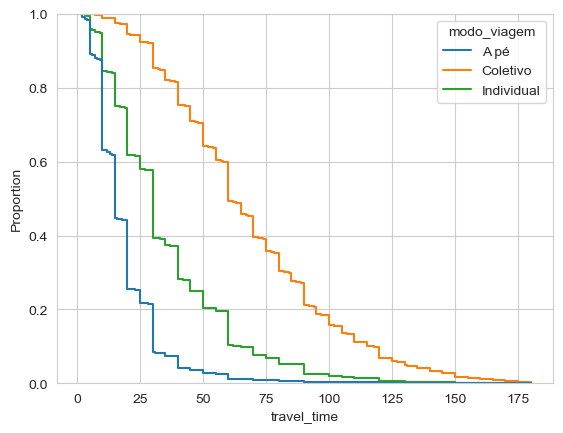

In [32]:
sns.ecdfplot(
    binned_hts,
    x='travel_time',
    weights='fe_via',
    hue='modo_viagem',
    complementary=True,
)

## Estimation

In [33]:
def spread_samples(df):
    return (
        df
        .reindex(
            df.index.repeat(df.fe_via.round())
            )
        .sort_values('travel_time')
        )

In [34]:
binned_hts = spread_samples(binned_hts)

Weirdly, travel times of the 95th percentile are similar to those of São Paulo...

In [35]:
binned_hts.groupby('modo_viagem').travel_time.describe(percentiles=[.5, .75, .95])

,count,mean,std,min,50%,75%,95%,max
modo_viagem,,,,,,,,
A pé,"1,310,064.00",18.95,14.26,1.00,15.00,25.00,40.00,180.00
Coletivo,"2,464,571.00",68.51,33.75,1.00,60.00,90.00,130.00,180.00
Individual,"2,645,308.00",35.14,24.71,1.00,30.00,46.00,90.00,180.00


In [36]:
binned_hts.travel_time.describe(percentiles=[.5, .75, .95])

count   6,419,943.00
mean           44.65
std            33.48
min             1.00
50%            35.00
75%            60.00
95%           110.00
max           180.00
Name: travel_time, dtype: float64

In [37]:
max_bin_by_mode = {
    'Coletivo': 240,
    'Individual': 240,
    'A pé': 240,
    }

fits_by_mode = fit_gravity(binned_hts)

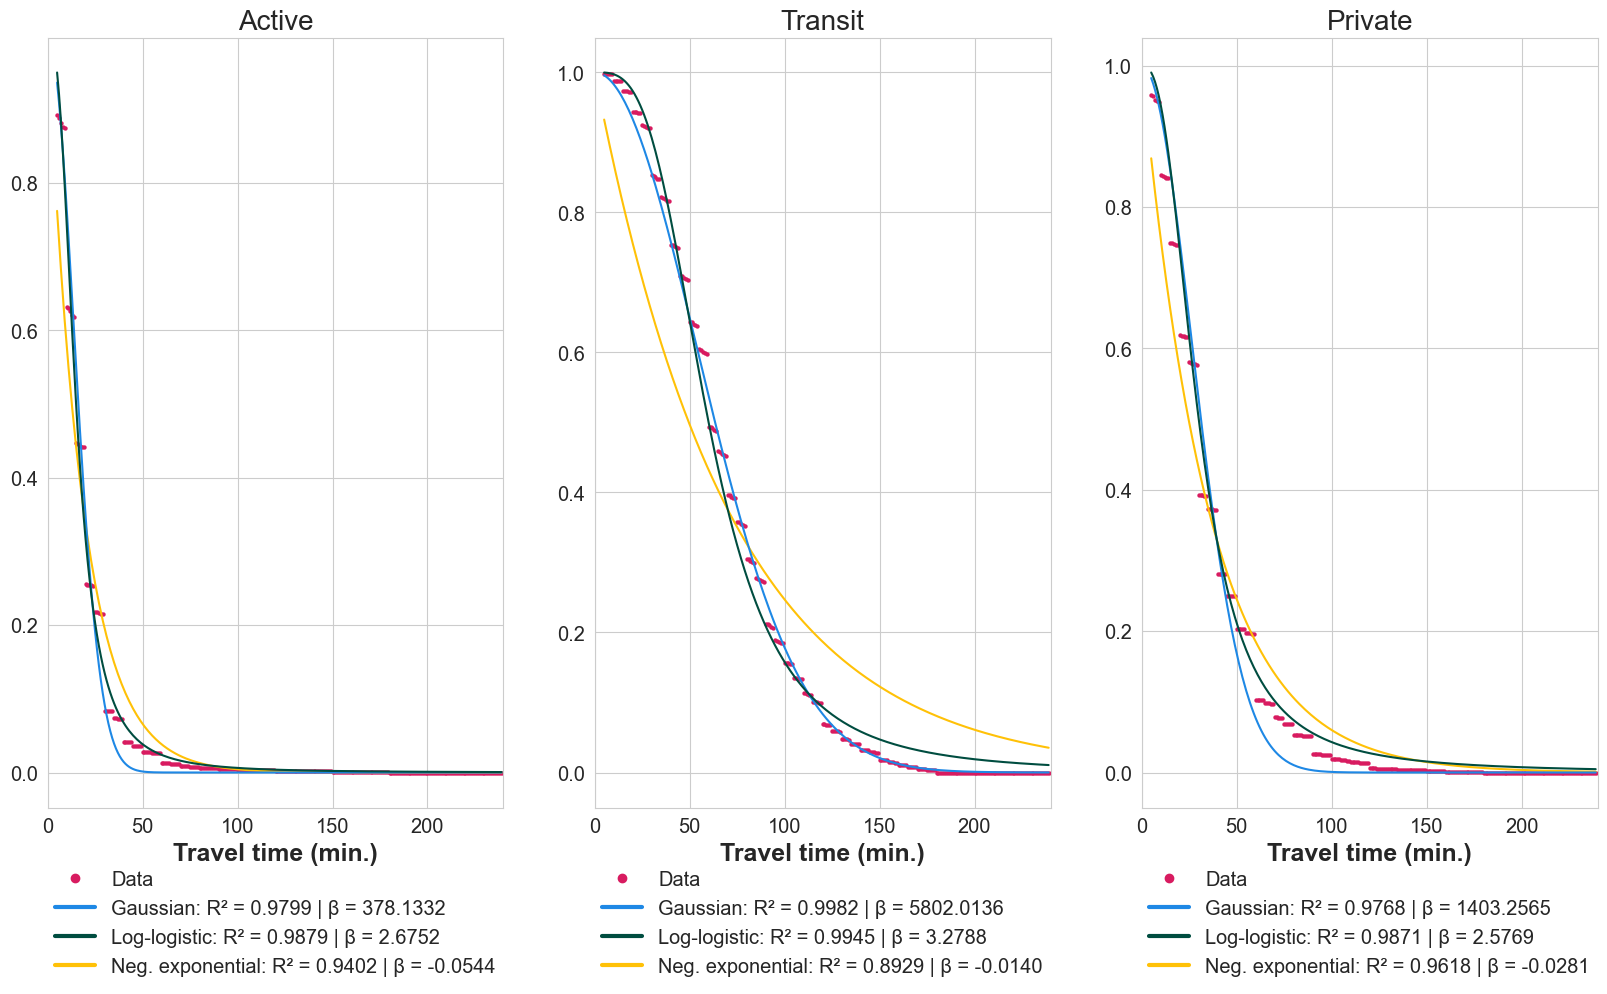

In [38]:
bh_params = print_fitted_curves(fits_by_mode)

In [39]:
bh_params

{'A pé': {'negative_exponential': {'beta': -0.0543653904555305,
   'r_squared': 0.9401802646235025,
   'median': 15.0},
  'gaussian': {'beta': 378.13315040161854,
   'r_squared': 0.9798858312096432,
   'median': 15.0},
  'log_logistic': {'beta': 2.675245293106648,
   'r_squared': 0.9878798564058505,
   'median': 15.0}},
 'Coletivo': {'negative_exponential': {'beta': -0.01398215251405415,
   'r_squared': 0.8929096222182533,
   'median': 60.0},
  'gaussian': {'beta': 5802.013550258791,
   'r_squared': 0.998163543385907,
   'median': 60.0},
  'log_logistic': {'beta': 3.2787829558223303,
   'r_squared': 0.994473721406266,
   'median': 60.0}},
 'Individual': {'negative_exponential': {'beta': -0.028122917561987475,
   'r_squared': 0.9617791813953498,
   'median': 30.0},
  'gaussian': {'beta': 1403.2565362335395,
   'r_squared': 0.9768283526264568,
   'median': 30.0},
  'log_logistic': {'beta': 2.576877885129239,
   'r_squared': 0.98706518079107,
   'median': 30.0}}}

# Sao Paulo

In [80]:
inpath = (
    db
    / 'sampa/origem_destino/OD-2017/Banco de Dados-OD2017/OD_2017_v1.sav'
)

hts = pd.read_spss(inpath)

In [84]:
hts.T.tail(50)

,0,1,2,3,4,5,6,7,8,9,...,183082,183083,183084,183085,183086,183087,183088,183089,183090,183091
n_viag,1.00,2.00,1.00,2.00,3.00,1.00,2.00,3.00,4.00,1.00,...,4.00,5.00,1.00,2.00,1.00,2.00,1.00,2.00,1.00,2.00
fe_via,22.13,22.13,18.88,18.88,18.88,22.13,22.13,22.13,22.13,22.44,...,83.32,83.32,89.33,89.33,89.33,89.33,55.55,55.55,55.55,55.55
dia_sem,Terça-feira,Terça-feira,Terça-feira,Terça-feira,Terça-feira,Terça-feira,Terça-feira,Terça-feira,Terça-feira,Terça-feira,...,Sexta-feira,Sexta-feira,Sexta-feira,Sexta-feira,Sexta-feira,Sexta-feira,Sexta-feira,Sexta-feira,Sexta-feira,Sexta-feira
tot_viag,2.00,2.00,3.00,3.00,3.00,4.00,4.00,4.00,4.00,4.00,...,5.00,5.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00
zona_o,1.00,3.00,1.00,82.00,84.00,1.00,1.00,1.00,1.00,1.00,...,517.00,517.00,517.00,517.00,517.00,517.00,517.00,517.00,517.00,517.00
muni_o,São Paulo,São Paulo,São Paulo,São Paulo,São Paulo,São Paulo,São Paulo,São Paulo,São Paulo,São Paulo,...,Pirapora do Bom Jesus,Pirapora do Bom Jesus,Pirapora do Bom Jesus,Pirapora do Bom Jesus,Pirapora do Bom Jesus,Pirapora do Bom Jesus,Pirapora do Bom Jesus,Pirapora do Bom Jesus,Pirapora do Bom Jesus,Pirapora do Bom Jesus
co_o_x,"333,743.00","333,104.00","333,743.00","327,503.00","329,431.00","333,814.00","333,453.00","333,814.00","333,453.00","333,814.00",...,"294,735.00","294,881.00","294,618.00","294,735.00","294,618.00","294,735.00","295,243.00","295,327.00","295,243.00","295,415.00"
co_o_y,"7,394,463.00","7,394,476.00","7,394,463.00","7,392,159.00","7,395,939.00","7,394,428.00","7,394,501.00","7,394,428.00","7,394,501.00","7,394,428.00",...,"7,410,561.00","7,411,254.00","7,410,518.00","7,410,561.00","7,410,518.00","7,410,561.00","7,411,456.00","7,410,920.00","7,411,456.00","7,410,915.00"
zona_d,3.00,1.00,82.00,84.00,1.00,1.00,1.00,1.00,1.00,1.00,...,517.00,517.00,517.00,517.00,517.00,517.00,517.00,517.00,517.00,517.00
muni_d,São Paulo,São Paulo,São Paulo,São Paulo,São Paulo,São Paulo,São Paulo,São Paulo,São Paulo,São Paulo,...,Pirapora do Bom Jesus,Pirapora do Bom Jesus,Pirapora do Bom Jesus,Pirapora do Bom Jesus,Pirapora do Bom Jesus,Pirapora do Bom Jesus,Pirapora do Bom Jesus,Pirapora do Bom Jesus,Pirapora do Bom Jesus,Pirapora do Bom Jesus


In [5]:
hts = (
    hts
    .loc[
        ((hts.muni_o == 'São Paulo') | (hts.muni_d == 'São Paulo'))
        & (hts.zona_o != hts.zona_d)
        ]
    .reindex(
        columns=[
            'muni_o',
            'muni_d',
            'zona_o',
            'zona_d',
            'tipvg',
            'fe_via',
            'duracao',
        ]
    )
    .rename(columns={
        'tipvg': 'modo_viagem',
        })
)

In [6]:
hts.head()

,muni_o,muni_d,zona_o,zona_d,modo_viagem,fe_via,duracao
0,São Paulo,São Paulo,1.00,3.00,A pé,22.13,10.00
1,São Paulo,São Paulo,3.00,1.00,A pé,22.13,10.00
2,São Paulo,São Paulo,1.00,82.00,Coletivo,18.88,50.00
3,São Paulo,São Paulo,82.00,84.00,Coletivo,18.88,60.00
4,São Paulo,São Paulo,84.00,1.00,Individual,18.88,40.00


In [7]:
def bin_trips(df):
    bins = np.arange(0, df.duracao.max() + 1, 1)
    labels = [b for b in bins[1:]]

    df['travel_time'] = pd.cut(
        df['duracao'],
        bins=bins,
        labels=labels,
        include_lowest=True,
        )

    return (
        df
        .groupby(
            ['modo_viagem', 'travel_time'],
            as_index=False,
            observed=True,
            )
        .agg({'fe_via': 'sum'})
        .pipe(
            lambda x: x.loc[x.modo_viagem != 'Bicicleta']
            )
        .astype({
            'travel_time': 'int',
            'modo_viagem': 'str'
            })
        )

In [8]:
binned_hts = bin_trips(hts)

binned_hts.head(2)

,modo_viagem,travel_time,fe_via
0,A pé,1,"13,461.93"
1,A pé,2,"25,145.20"


<Axes: xlabel='travel_time', ylabel='Proportion'>

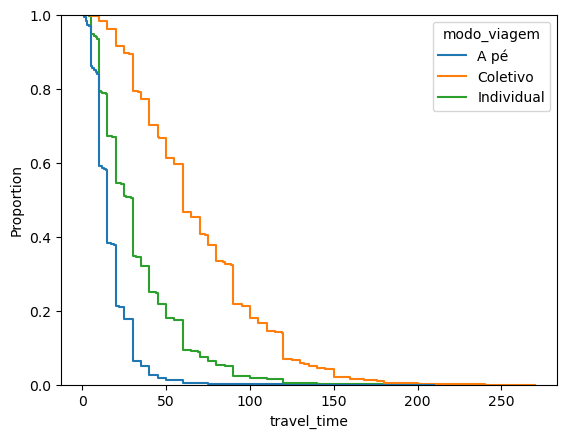

In [9]:
sns.ecdfplot(
    binned_hts,
    x='travel_time',
    weights='fe_via',
    hue='modo_viagem',
    complementary=True,
)

## Estimation

In [10]:
def spread_samples(df):
    return (
        df
        .reindex(
            df.index.repeat(df.fe_via.round())
            )
        .sort_values('travel_time')
        )

In [11]:
binned_hts = spread_samples(binned_hts)

In [12]:
binned_hts.travel_time.describe(percentiles=[.5, .75, .95, .975])

count   20,044,664.00
mean            49.85
std             37.51
min              1.00
50%             40.00
75%             70.00
95%            120.00
97.5%          140.00
max            270.00
Name: travel_time, dtype: float64

In [13]:
binned_hts.groupby('modo_viagem').travel_time.describe(percentiles=[.5, .75, .95, .975])

,count,mean,std,min,50%,75%,95%,97.5%,max
modo_viagem,,,,,,,,,
A pé,"2,374,861.00",17.01,11.48,1.00,15.00,20.00,36.00,44.00,210.00
Coletivo,"10,550,850.00",68.90,37.67,3.00,60.00,90.00,140.00,150.00,270.00
Individual,"7,118,953.00",32.56,24.85,2.00,30.00,40.00,90.00,90.00,240.00


In [14]:
# Thanks to https://stackoverflow.com/a/49813634/15994934

class FitClass:
    def __init__(self, hts):
        self.bus_median = (
            hts
            .loc[hts.modo_viagem == 'Coletivo']
            .travel_time
            .median()
            )
        self.car_median = (
            hts
            .loc[hts.modo_viagem == 'Individual']
            .travel_time
            .median()
            )
        self.foot_median = (
            hts
            .loc[hts.modo_viagem == 'A pé']
            .travel_time
            .median()
            )

    def gaussian(self, c, b):
        return np.exp(-c**2 / b)
    
    def log_logistic(self, c, b):
        return 1 / (1 + (c / self.median)**b)
    
    def negative_exponential(self, c, b):
        return np.exp(b * c)

fit_funcs = FitClass(binned_hts)

In [15]:
func_colors = {
    'gaussian':'#1E88E5',
    'log_logistic': '#004D40',
    'negative_exponential': '#FFC107',
    }

In [16]:
def vars_for_fitting(mode, data):
    res = ecdf(data.travel_time)
    max_bin = max_bin_by_mode.get(mode)

    X = np.array([x for x in range(5, max_bin)])
    Y = np.array([1 - res.cdf.evaluate(x) for x in X])
    
    fit_funcs.median = fit_funcs.bus_median
    if mode == 'Individual':
        fit_funcs.median = fit_funcs.car_median
    if mode == 'A pé':
        fit_funcs.median = fit_funcs.foot_median
    
    return X, Y, fit_funcs.median


def fit_mode(mode, data):
    X, Y, median = vars_for_fitting(mode, data)

    funcs = [
        'negative_exponential',
        'gaussian',
        'log_logistic',
        ]
    
    fitted_params = {}
    for func in funcs:
        res = curve_fit(
            getattr(fit_funcs, func),
            X,
            Y,
            maxfev=1_000,
            )
        fitted_params[func] = {
            'response': [r[0] for r in res],
            'X': X,
            'Y': Y,
            'median': median,
            }

    return fitted_params
    

def fit_gravity(df):
    fits_by_mode = {}
    for mode, data in df.groupby('modo_viagem'):
        fits_by_mode[mode] = fit_mode(mode, data)

    return fits_by_mode

In [17]:
max_bin_by_mode = {
    'Coletivo': 240,
    'Individual': 240,
    'A pé': 240,
    }

fits_by_mode = fit_gravity(binned_hts)

In [18]:
def write_legend(ax, func_params):
    custom_lines = [
        Line2D([0], [0], color='#D81B60', lw=0, marker='o'),
        Line2D([0], [0], color='#1E88E5', lw=3),
        Line2D([0], [0], color='#004D40', lw=3),
        Line2D([0], [0], color='#FFC107', lw=3),
        ]

    gauss_b, gauss_r, _ = func_params.get('gaussian').values()
    exp_b, exp_r, _ = func_params.get('negative_exponential').values()
    log_b, log_r, _ = func_params.get('log_logistic').values()

    labels = [
        'Data',
        f"Gaussian: R\N{SUPERSCRIPT TWO} = {gauss_r:.4f} | \N{greek small letter beta} = {gauss_b:.4f}",
        f"Log-logistic: R\N{SUPERSCRIPT TWO} = {log_r:.4f} | \N{greek small letter beta} = {log_b:.4f}",
        f"Neg. exponential: R\N{SUPERSCRIPT TWO} = {exp_r:.4f} | \N{greek small letter beta} = {exp_b:.4f}",
        ]
    
    ax.legend(
        custom_lines,
        labels,
        fontsize='x-large',
        bbox_to_anchor=(.5, -.15),
        loc='center',
        frameon=False
        )

In [19]:
def _r_squared(Y, y_hat):
    Y = np.array(Y)
    y_hat = np.array(y_hat)

    sum_squared_residuals = np.square(Y - y_hat).sum()
    total_sum_squares = np.square(Y - np.mean(Y)).sum()

    return 1 - (sum_squared_residuals / total_sum_squares)
    

def goodness_of_fit(func_form, b, X, Y):
    curve_equation = getattr(fit_funcs, func_form)
    y_hat = curve_equation(X, b)

    r = _r_squared(Y, y_hat)

    return y_hat, r

In [20]:
def print_fitted_curves(fits_by_mode):
    f, axes = plt.subplots(figsize=(20, 10), ncols=3)
    axes = axes.flatten()

    mode_params = {}
    for ax, (mode, fits) in zip(axes, fits_by_mode.items()):
        if mode == 'Individual':
            title = 'Private'
            fit_funcs.median = fit_funcs.car_median
        if mode == 'Coletivo':
            fit_funcs.median = fit_funcs.bus_median
            title = 'Transit'

        if mode == 'A pé':
            title = 'Active'
            fit_funcs.median = fit_funcs.foot_median
        
        mode_params[mode] = _curves_by_mode(fits, ax)

        ax.set_title(title, fontsize=20)
        ax.set_xlabel('Travel time (min.)', fontsize=18, weight='bold')
        ax.tick_params(
            axis='both',
            labelsize='x-large',
            )
        ax.set_xlim(0, 240)
            
    return mode_params


def _plot_data(X, Y, ax):
    sns.scatterplot(
        ax=ax,
        x=X,
        y=Y,
        c='#D81B60',
        linewidths=0,
        s=10,
        )

def _plot_curve(func_form, X, Y, ax):
    sns.lineplot(
        ax=ax,
        x=X,
        y=Y,
        c=func_colors.get(func_form),
        legend=True,
        )


def _curves_by_mode(fits, ax):
    func_params = {}
    for func_form, params in fits.items():
        (b, _), X, Y, median = params.values()
        y_hat, r = goodness_of_fit(func_form, b, X, Y)
        
        _plot_curve(func_form, X, y_hat, ax)

        func_params[func_form] = {
            'beta': b,
            'r_squared': r,
            'median': median
            }
        
    _plot_data(X, Y, ax)

    write_legend(ax, func_params)

    return func_params


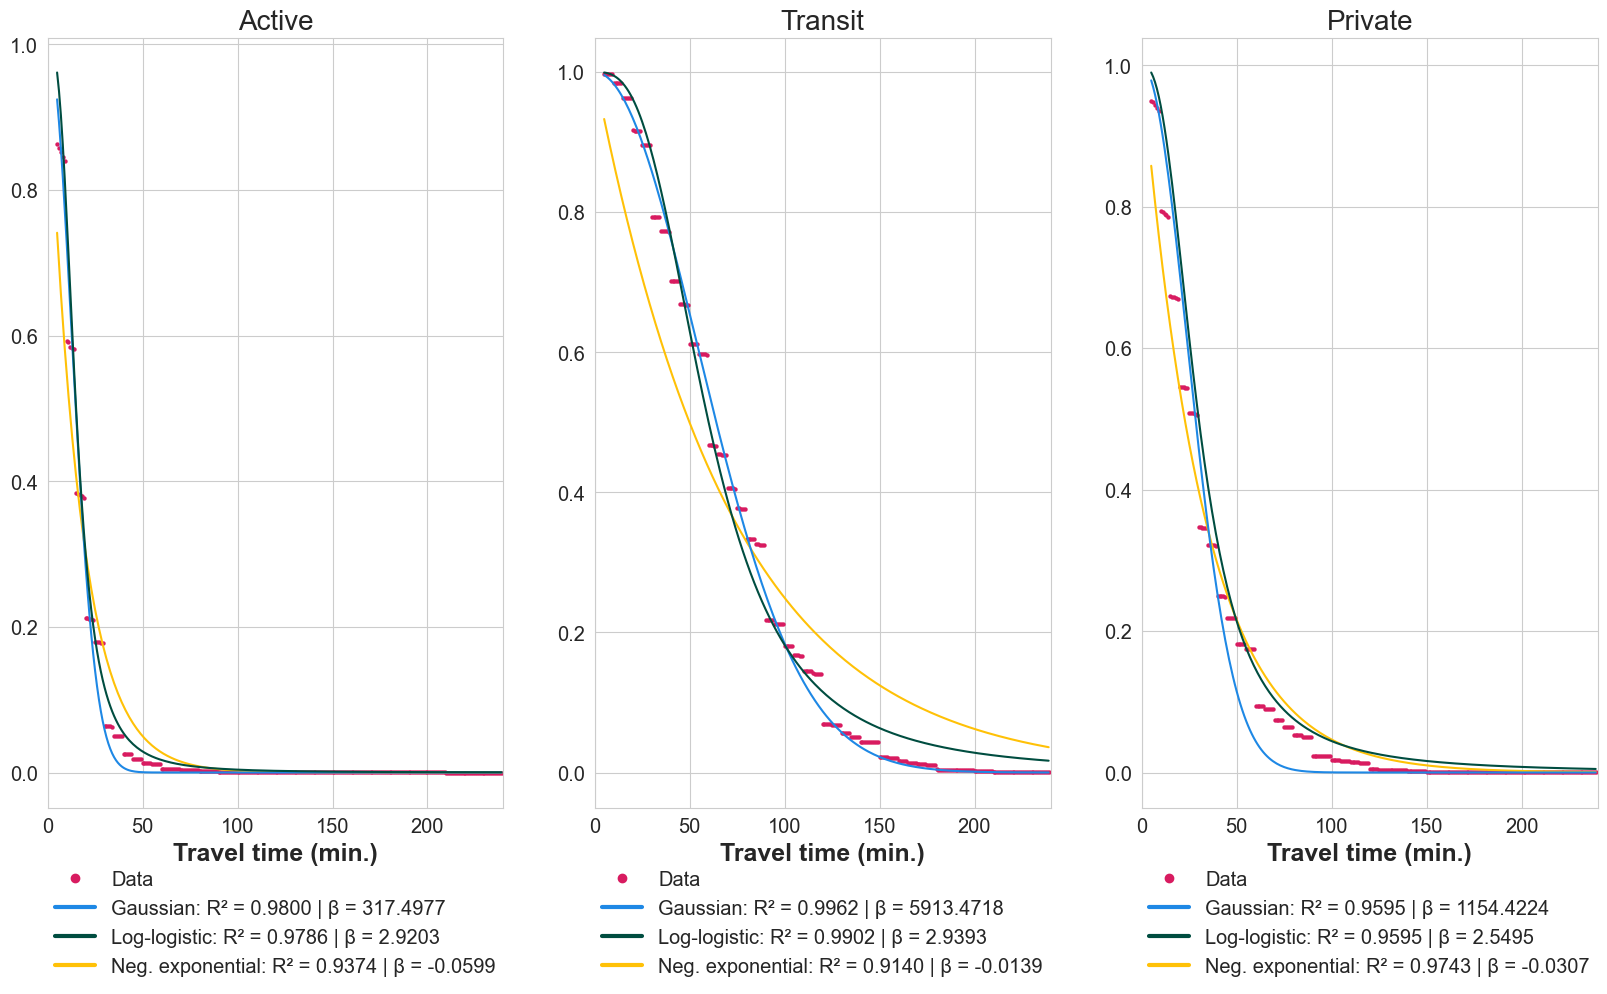

In [21]:
sns.set_style("whitegrid")
sp_params = print_fitted_curves(fits_by_mode)

In [22]:
sp_params

{'A pé': {'negative_exponential': {'beta': -0.05992219211150914,
   'r_squared': 0.9373819023163662,
   'median': 15.0},
  'gaussian': {'beta': 317.4977301678102,
   'r_squared': 0.9800112120146562,
   'median': 15.0},
  'log_logistic': {'beta': 2.920261716498597,
   'r_squared': 0.9786232258546973,
   'median': 15.0}},
 'Coletivo': {'negative_exponential': {'beta': -0.013887123324867664,
   'r_squared': 0.9139872908608002,
   'median': 60.0},
  'gaussian': {'beta': 5913.471768187842,
   'r_squared': 0.9962497403677307,
   'median': 60.0},
  'log_logistic': {'beta': 2.939279072699609,
   'r_squared': 0.9902151186370115,
   'median': 60.0}},
 'Individual': {'negative_exponential': {'beta': -0.030671294392072824,
   'r_squared': 0.9742708918955559,
   'median': 30.0},
  'gaussian': {'beta': 1154.42239703506,
   'r_squared': 0.9595497004436527,
   'median': 30.0},
  'log_logistic': {'beta': 2.549531247608968,
   'r_squared': 0.959507625268043,
   'median': 30.0}}}

## Backup

In [23]:
with open('outputs/S100/sp_od_fitting.json', 'w') as fp:
    json.dump(sp_params, fp)

## Backup

In [40]:
with open('outputs/S100/bh_od_fitting.json', 'w') as fp:
    json.dump(bh_params, fp)